# CIC-DDoS2019 Complete Analysis

**Purpose:** Complete the CIC-DDoS2019 exploratory analysis as the third dataset in the CIC-based IDS comparison.

In [ ]:
import os
import sys
import subprocess
from pathlib import Path

# Install dependencies
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "-U",
        "kaggle", "pandas", "numpy", "pyarrow",
        "scipy", "scikit-learn", "matplotlib"
    ],
    check=True
)

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from collections import Counter

# Kaggle authentication through current Colab Secret mechanism
try:
    from google.colab import userdata
    token = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    token = None

if not token:
    raise RuntimeError(
        "Add a Colab Secret named KAGGLE_API_TOKEN containing "
        "your current Kaggle API token."
    )

os.environ["KAGGLE_API_TOKEN"] = token

# Paths
BASE = Path("/content/cicddos2019_work")
DL = BASE / "download"
OUT = BASE / "results"

DL.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Download current Kaggle dataset
DATASET_ID = "dhoogla/cicddos2019"

subprocess.run(
    [
        sys.executable, "-m", "kaggle",
        "datasets", "download",
        "-d", DATASET_ID,
        "-p", str(DL),
        "--unzip"
    ],
    check=True
)

# Locate current data files
parquet_files = sorted(DL.rglob("*.parquet"))
csv_files = sorted(DL.rglob("*.csv"))

print("CSV files:", len(csv_files))
print("Parquet files:", len(parquet_files))

if not parquet_files and not csv_files:
    print("\nDownloaded directory contents:")
    for p in sorted(DL.rglob("*")):
        print(" ", p)

    raise FileNotFoundError(
        "No CSV or Parquet data files were found."
    )

# Prefer Parquet because this notebook is explicitly designed
# for the current Parquet representation.
files = parquet_files if parquet_files else csv_files

print("\nUsing:", "Parquet" if parquet_files else "CSV fallback")
print("Data files:", len(files))

for f in files:
    print(" ", f.relative_to(DL))

CSV files: 0
Parquet files: 17

Using: Parquet
Data files: 17
  DNS-testing.parquet
  LDAP-testing.parquet
  LDAP-training.parquet
  MSSQL-testing.parquet
  MSSQL-training.parquet
  NTP-testing.parquet
  NetBIOS-testing.parquet
  NetBIOS-training.parquet
  Portmap-training.parquet
  SNMP-testing.parquet
  Syn-testing.parquet
  Syn-training.parquet
  TFTP-testing.parquet
  UDP-testing.parquet
  UDP-training.parquet
  UDPLag-testing.parquet
  UDPLag-training.parquet


## 2. Format-aware data access

All later cells use the helpers below. For the current dataset, Parquet metadata and PyArrow are used wherever possible so the notebook does not accidentally call `pd.read_csv()` on binary Parquet files.

In [ ]:
CHUNK_SIZE = 250_000

def get_columns(path):
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return [
            str(x).strip()
            for x in pq.ParquetFile(path).schema.names
        ]

    return [
        str(x).strip()
        for x in pd.read_csv(
            path,
            nrows=0,
            low_memory=False,
            encoding_errors="replace"
        ).columns
    ]


def get_row_count(path):
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return int(pq.ParquetFile(path).metadata.num_rows)

    total = 0
    for chunk in pd.read_csv(
        path,
        chunksize=CHUNK_SIZE,
        low_memory=False,
        encoding_errors="replace"
    ):
        total += len(chunk)
    return total


def get_label_column(columns):
    candidates = {
        "label", "class", "attack", "target",
        "category", "type", "traffic"
    }

    for c in columns:
        if str(c).strip().lower() in candidates:
            return c

    # Useful fallback for common CIC naming
    for c in columns:
        if "label" in str(c).lower():
            return c

    return None


def load_data(path, columns=None):
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path, columns=columns)

    return pd.read_csv(
        path,
        usecols=columns,
        low_memory=False,
        encoding_errors="replace"
    )


def numeric_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [
        c for c in df.select_dtypes(include=np.number).columns
        if c not in exclude
    ]


# Establish common schema
common = get_columns(files[0])

for f in files[1:]:
    cols = get_columns(f)
    common = [c for c in common if c in cols]

label = get_label_column(common)

print("Common columns:", len(common))
print("Label column:", label)

if label is None:
    print("\nWARNING: Could not automatically identify the label column.")

print("\nColumns:")
for c in common:
    print(" ", c)

Common columns: 78
Label column: Label

Columns:
  Protocol
  Flow Duration
  Total Fwd Packets
  Total Backward Packets
  Fwd Packets Length Total
  Bwd Packets Length Total
  Fwd Packet Length Max
  Fwd Packet Length Min
  Fwd Packet Length Mean
  Fwd Packet Length Std
  Bwd Packet Length Max
  Bwd Packet Length Min
  Bwd Packet Length Mean
  Bwd Packet Length Std
  Flow Bytes/s
  Flow Packets/s
  Flow IAT Mean
  Flow IAT Std
  Flow IAT Max
  Flow IAT Min
  Fwd IAT Total
  Fwd IAT Mean
  Fwd IAT Std
  Fwd IAT Max
  Fwd IAT Min
  Bwd IAT Total
  Bwd IAT Mean
  Bwd IAT Std
  Bwd IAT Max
  Bwd IAT Min
  Fwd PSH Flags
  Bwd PSH Flags
  Fwd URG Flags
  Bwd URG Flags
  Fwd Header Length
  Bwd Header Length
  Fwd Packets/s
  Bwd Packets/s
  Packet Length Min
  Packet Length Max
  Packet Length Mean
  Packet Length Std
  Packet Length Variance
  FIN Flag Count
  SYN Flag Count
  RST Flag Count
  PSH Flag Count
  ACK Flag Count
  URG Flag Count
  CWE Flag Count
  ECE Flag Count
  Down/Up Rati

## 3. File inventory and dataset overview

In [ ]:
inventory = []

for f in files:
    cols = get_columns(f)
    inventory.append({
        "file": f.name,
        "format": f.suffix.lower().replace(".", ""),
        "records": get_row_count(f),
        "columns": len(cols),
        "file_size_mb": round(f.stat().st_size / (1024**2), 3)
    })

inventory_df = pd.DataFrame(inventory)

summary = pd.DataFrame([{
    "dataset": "CIC-DDoS2019",
    "source_files": len(files),
    "total_records": int(inventory_df["records"].sum()),
    "common_columns": len(common),
    "label": label,
    "storage_format": "Parquet" if parquet_files else "CSV"
}])

inventory_df.to_csv(OUT / "17_file_inventory.csv", index=False)
summary.to_csv(OUT / "17_dataset_summary.csv", index=False)

display(summary)
display(inventory_df)

,dataset,source_files,total_records,common_columns,label,storage_format
0,CIC-DDoS2019,17,431371,78,Label,Parquet


,file,format,records,columns,file_size_mb
0,DNS-testing.parquet,parquet,6703,78,0.487
1,LDAP-testing.parquet,parquet,2831,78,0.214
2,LDAP-training.parquet,parquet,6715,78,0.591
3,MSSQL-testing.parquet,parquet,8083,78,0.402
4,MSSQL-training.parquet,parquet,10974,78,0.554
5,NTP-testing.parquet,parquet,134674,78,9.047
6,NetBIOS-testing.parquet,parquet,2225,78,0.242
7,NetBIOS-training.parquet,parquet,1631,78,0.213
8,Portmap-training.parquet,parquet,5105,78,0.544
9,SNMP-testing.parquet,parquet,4018,78,0.256


## 4. Schema and data types

In [ ]:
# Read schema from the first file.
sample = load_data(files[0], columns=common)

schema_rows = []

for c in common:
    schema_rows.append({
        "column": c,
        "dtype": str(sample[c].dtype),
        "numeric": pd.api.types.is_numeric_dtype(sample[c]),
        "missing_in_sample": int(sample[c].isna().sum()),
        "unique_in_sample": int(sample[c].nunique(dropna=True))
    })

schema_df = pd.DataFrame(schema_rows)

schema_df.to_csv(OUT / "17_schema.csv", index=False)

print("Sample shape:", sample.shape)
display(schema_df)

Sample shape: (6703, 78)


,column,dtype,numeric,missing_in_sample,unique_in_sample
0,Protocol,int8,True,0,3
1,Flow Duration,int32,True,0,2263
2,Total Fwd Packets,int16,True,0,88
3,Total Backward Packets,int16,True,0,90
4,Fwd Packets Length Total,float32,True,0,865
...,...,...,...,...,...
73,Idle Mean,float32,True,0,369
74,Idle Std,float32,True,0,270
75,Idle Max,float32,True,0,366
76,Idle Min,float32,True,0,360


## 5. Data-quality analysis

The analysis below is performed file-by-file and feature-by-feature.

Metrics:
- missing values
- infinite values
- exact duplicate rows
- constant features
- near-constant features
- minimum / maximum values
- approximate unique counts

The notebook uses Parquet files directly.

In [ ]:
quality_rows = []
duplicate_rows = []
global_min = {c: np.inf for c in common}
global_max = {c: -np.inf for c in common}
global_unique = {c: set() for c in common}

# Keep unique-value tracking bounded for high-cardinality columns.
# This is sufficient for identifying constants and low-cardinality
# features without retaining every unique value indefinitely.
UNIQUE_TRACK_LIMIT = 1000

for f in files:
    df = load_data(f, columns=common)

    num_cols = numeric_columns(df, exclude=[label] if label else None)

    missing = int(df.isna().sum().sum())

    inf_count = 0
    if num_cols:
        arr = df[num_cols].to_numpy(dtype=np.float64, copy=False)
        inf_count = int(np.isinf(arr).sum())

        for c in num_cols:
            s = pd.to_numeric(df[c], errors="coerce")
            finite = s[np.isfinite(s)]

            if len(finite):
                global_min[c] = min(global_min[c], float(finite.min()))
                global_max[c] = max(global_max[c], float(finite.max()))

            if len(global_unique[c]) <= UNIQUE_TRACK_LIMIT:
                vals = pd.Series(s.dropna().unique())
                global_unique[c].update(vals.tolist()[:UNIQUE_TRACK_LIMIT])

    duplicates = int(df.duplicated().sum())

    duplicate_rows.append({
        "file": f.name,
        "records": len(df),
        "duplicate_rows": duplicates
    })

    quality_rows.append({
        "file": f.name,
        "records": len(df),
        "columns": len(df.columns),
        "missing_values": missing,
        "infinite_values": inf_count,
        "duplicate_rows": duplicates
    })

    del df

quality_df = pd.DataFrame(quality_rows)
duplicate_df = pd.DataFrame(duplicate_rows)

feature_quality = []

for c in common:
    mn = global_min.get(c, np.inf)
    mx = global_max.get(c, -np.inf)
    finite_range_known = np.isfinite(mn) and np.isfinite(mx)

    feature_quality.append({
        "feature": c,
        "global_min": mn if finite_range_known else np.nan,
        "global_max": mx if finite_range_known else np.nan,
        "constant": bool(
            finite_range_known and mn == mx
        ),
        "approx_unique_leq_1000": (
            len(global_unique[c])
            if len(global_unique[c]) <= UNIQUE_TRACK_LIMIT
            else UNIQUE_TRACK_LIMIT + 1
        )
    })

feature_quality_df = pd.DataFrame(feature_quality)

quality_df.to_csv(OUT / "17_file_data_quality.csv", index=False)
duplicate_df.to_csv(OUT / "17_duplicates_by_file.csv", index=False)
feature_quality_df.to_csv(OUT / "17_feature_quality.csv", index=False)

quality_summary = pd.DataFrame([{
    "total_records": int(quality_df["records"].sum()),
    "total_missing_values": int(quality_df["missing_values"].sum()),
    "total_infinite_values": int(quality_df["infinite_values"].sum()),
    "total_duplicate_rows": int(quality_df["duplicate_rows"].sum()),
    "constant_features": int(feature_quality_df["constant"].sum())
}])

quality_summary.to_csv(OUT / "17_quality_summary.csv", index=False)

display(quality_summary)
display(quality_df)
display(feature_quality_df)

,total_records,total_missing_values,total_infinite_values,total_duplicate_rows,constant_features
0,431371,0,0,0,12


,file,records,columns,missing_values,infinite_values,duplicate_rows
0,DNS-testing.parquet,6703,78,0,0,0
1,LDAP-testing.parquet,2831,78,0,0,0
2,LDAP-training.parquet,6715,78,0,0,0
3,MSSQL-testing.parquet,8083,78,0,0,0
4,MSSQL-training.parquet,10974,78,0,0,0
5,NTP-testing.parquet,134674,78,0,0,0
6,NetBIOS-testing.parquet,2225,78,0,0,0
7,NetBIOS-training.parquet,1631,78,0,0,0
8,Portmap-training.parquet,5105,78,0,0,0
9,SNMP-testing.parquet,4018,78,0,0,0


,feature,global_min,global_max,constant,approx_unique_leq_1000
0,Protocol,0.0,17.0,False,3
1,Flow Duration,1.0,119998742.0,False,1001
2,Total Fwd Packets,1.0,86666.0,False,354
3,Total Backward Packets,0.0,31700.0,False,454
4,Fwd Packets Length Total,0.0,15266416.0,False,1001
...,...,...,...,...,...
73,Idle Mean,0.0,119219448.0,False,1001
74,Idle Std,0.0,69614024.0,False,1001
75,Idle Max,0.0,119219448.0,False,1001
76,Idle Min,0.0,119219448.0,False,1001


## 6. Class distribution

In [ ]:
if label is None:
    print("No label column identified; class analysis skipped.")
else:
    class_counts = Counter()
    file_class_rows = []

    for f in files:
        df = load_data(f, columns=[label])

        vc = df[label].astype("string").fillna("<MISSING>").value_counts()

        for cls, n in vc.items():
            class_counts[str(cls)] += int(n)
            file_class_rows.append({
                "file": f.name,
                "label": str(cls),
                "records": int(n)
            })

        del df

    total = sum(class_counts.values())

    class_df = pd.DataFrame([
        {
            "label": cls,
            "records": int(n),
            "percentage": 100.0 * n / total if total else 0.0
        }
        for cls, n in class_counts.items()
    ]).sort_values("records", ascending=False)

    class_df["imbalance_ratio_vs_min"] = (
        class_df["records"] / class_df["records"].min()
        if len(class_df) else np.nan
    )

    file_class_df = pd.DataFrame(file_class_rows)

    class_df.to_csv(OUT / "17_class_distribution.csv", index=False)
    file_class_df.to_csv(OUT / "17_class_distribution_by_file.csv", index=False)

    print("Number of classes:", len(class_df))
    display(class_df)

Number of classes: 18


,label,records,percentage,imbalance_ratio_vs_min
7,DrDoS_NTP,121368,28.135410,2379.764706
12,TFTP,98917,22.930841,1939.549020
1,Benign,97831,22.679086,1918.254902
11,Syn,49373,11.445600,968.098039
14,UDP,18090,4.193606,354.705882
13,DrDoS_UDP,10420,2.415554,204.313725
15,UDP-lag,8872,2.056698,173.960784
6,MSSQL,8523,1.975793,167.117647
5,DrDoS_MSSQL,6212,1.440060,121.803922
0,DrDoS_DNS,3669,0.850544,71.941176


## 7. Class distribution visualization

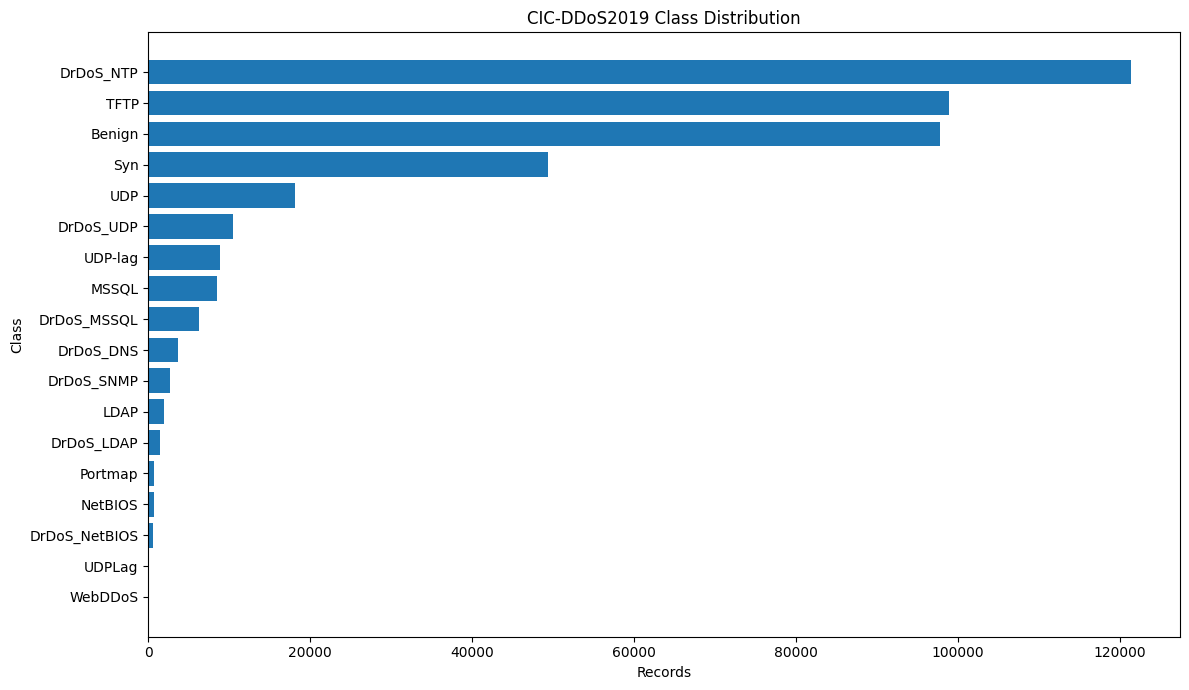

In [ ]:
# Class distribution plot

if label is not None and "class_df" in globals():
    plt.figure(figsize=(12, 7))
    plt.barh(class_df["label"].astype(str), class_df["records"])
    plt.gca().invert_yaxis()
    plt.xlabel("Records")
    plt.ylabel("Class")
    plt.title("CIC-DDoS2019 Class Distribution")
    plt.tight_layout()
    plt.savefig(OUT / "17_class_distribution.png", dpi=180)
    plt.show()

## 8. Feature distribution and skew

For every numeric feature, the notebook calculates:
- mean
- standard deviation
- minimum
- median
- maximum
- missing count
- infinite count
- approximate skewness

Statistics are aggregated across all source files.

In [ ]:
numeric = [
    c for c in common
    if c != label
]

# Determine numeric columns from schema
numeric = schema_df.loc[
    (schema_df["numeric"]) &
    (schema_df["column"] != label),
    "column"
].tolist()

stats_rows = []

for c in numeric:
    count = 0
    missing = 0
    inf_count = 0
    sum_x = 0.0
    sum_x2 = 0.0
    min_x = np.inf
    max_x = -np.inf
    values_for_skew = []

    for f in files:
        df = load_data(f, columns=[c])
        s = pd.to_numeric(df[c], errors="coerce")

        missing += int(s.isna().sum())

        arr = s.to_numpy(dtype=np.float64, copy=False)
        finite = arr[np.isfinite(arr)]

        inf_count += int(np.isinf(arr).sum())

        if len(finite):
            count += len(finite)
            sum_x += float(finite.sum())
            sum_x2 += float(np.square(finite).sum())
            min_x = min(min_x, float(finite.min()))
            max_x = max(max_x, float(finite.max()))

            # Keep a bounded sample for robust median/skew estimation.
            if len(values_for_skew) < 100_000:
                take = min(100_000 - len(values_for_skew), len(finite))
                values_for_skew.extend(finite[:take].tolist())

        del df

    if count:
        mean = sum_x / count
        variance = max((sum_x2 / count) - mean**2, 0.0)
        std = np.sqrt(variance)

        sample_values = np.asarray(values_for_skew, dtype=np.float64)

        median = float(np.median(sample_values)) if len(sample_values) else np.nan
        skew = (
            float(pd.Series(sample_values).skew())
            if len(sample_values) >= 3
            else np.nan
        )
    else:
        mean = std = median = skew = np.nan

    stats_rows.append({
        "feature": c,
        "count": count,
        "missing": missing,
        "infinite": inf_count,
        "mean": mean,
        "std": std,
        "min": min_x if np.isfinite(min_x) else np.nan,
        "median_sample": median,
        "max": max_x if np.isfinite(max_x) else np.nan,
        "skew_sample": skew
    })

feature_stats = pd.DataFrame(stats_rows)

feature_stats["abs_skew"] = feature_stats["skew_sample"].abs()
feature_stats["high_skew"] = feature_stats["abs_skew"] >= 2

feature_stats.to_csv(
    OUT / "17_numeric_feature_statistics.csv",
    index=False
)

display(feature_stats.sort_values("abs_skew", ascending=False).head(30))

,feature,count,missing,infinite,mean,std,min,median_sample,max,skew_sample,abs_skew,high_skew
2,Total Fwd Packets,431371,0,0,2.413912e+01,1.958887e+02,1.000000e+00,16.000000,86666.0,211.747450,211.747450,True
61,Subflow Fwd Packets,431371,0,0,2.413912e+01,1.958887e+02,1.000000e+00,16.000000,86666.0,211.747450,211.747450,True
4,Fwd Packets Length Total,431371,0,0,9.416956e+03,3.445249e+04,0.000000e+00,6752.000000,15266416.0,177.574895,177.574895,True
62,Subflow Fwd Bytes,431371,0,0,9.416956e+03,3.445249e+04,0.000000e+00,6752.000000,15266416.0,177.574895,177.574895,True
5,Bwd Packets Length Total,431371,0,0,1.632896e+03,1.064055e+05,0.000000e+00,0.000000,58429504.0,149.516408,149.516408,True
64,Subflow Bwd Bytes,431371,0,0,1.632896e+03,1.064055e+05,0.000000e+00,0.000000,58429504.0,149.516408,149.516408,True
63,Subflow Bwd Packets,431371,0,0,2.472021e+00,5.637014e+01,0.000000e+00,0.000000,31700.0,128.525518,128.525518,True
3,Total Backward Packets,431371,0,0,2.472021e+00,5.637014e+01,0.000000e+00,0.000000,31700.0,128.525518,128.525518,True
35,Bwd Header Length,431371,0,0,-1.139719e+06,5.906510e+07,-1.700349e+10,0.000000,634024.0,-83.634554,83.634554,True
19,Flow IAT Min,431371,0,0,4.322362e+03,2.387267e+05,0.000000e+00,0.000000,51199892.0,77.733859,77.733859,True


## 9. Feature distribution plots

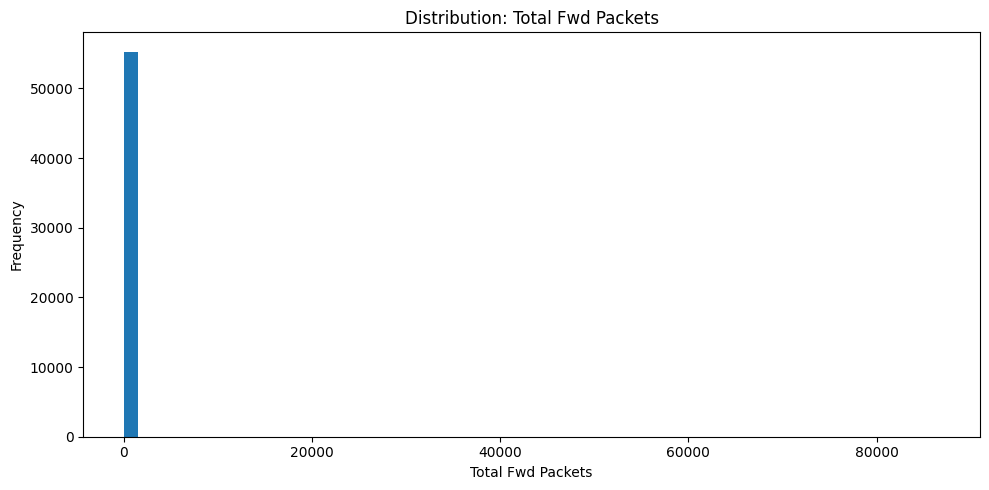

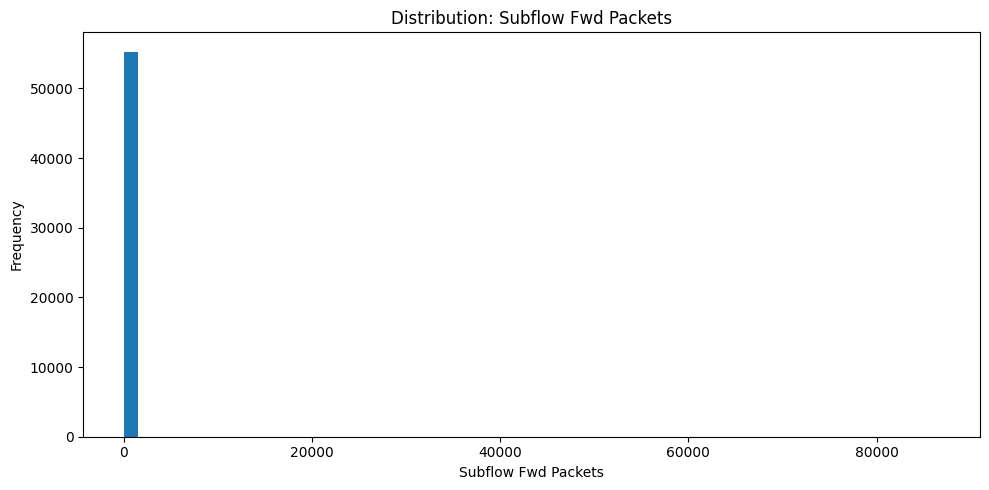

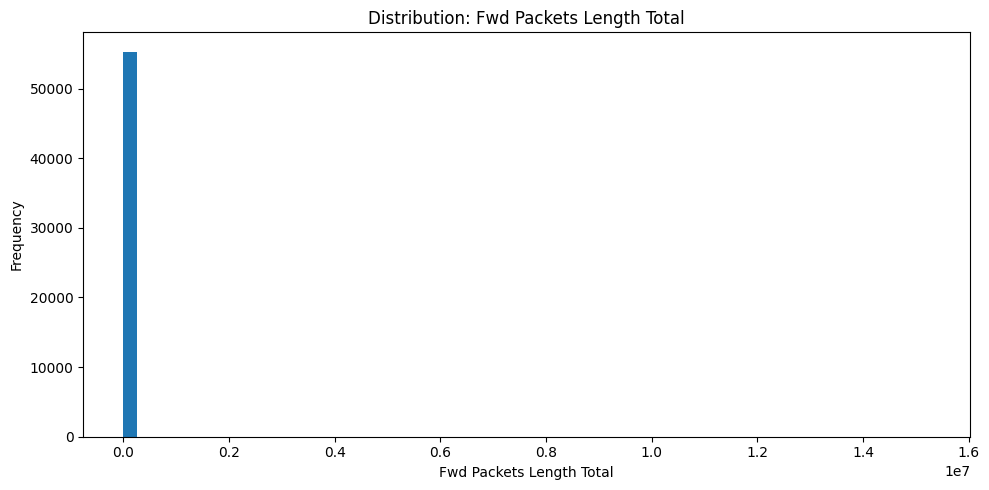

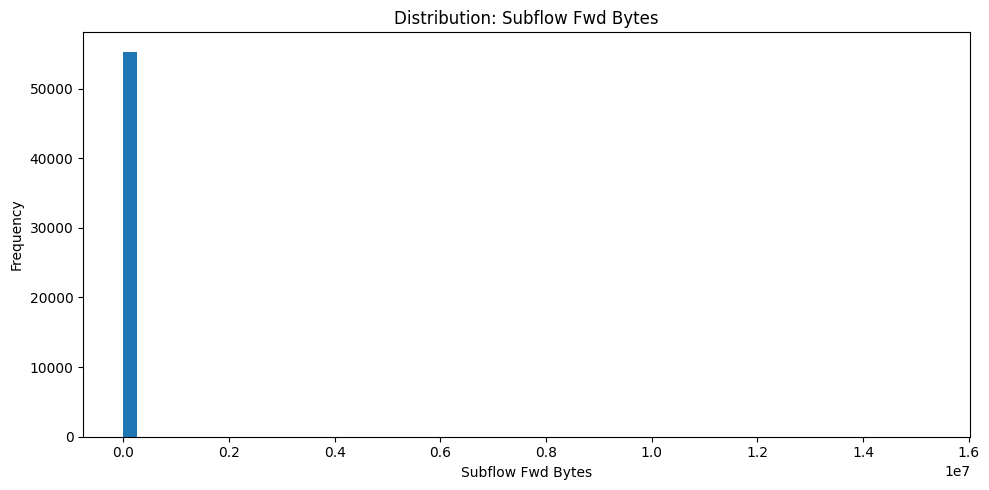

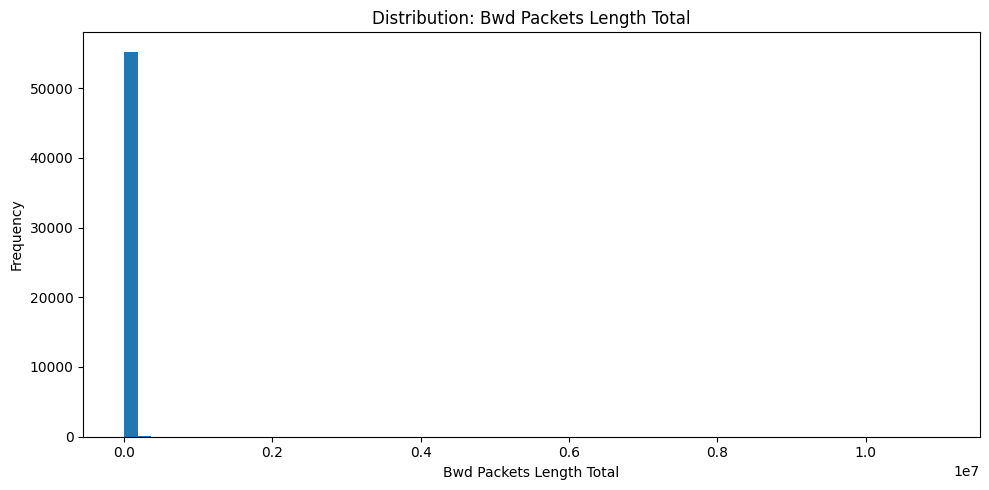

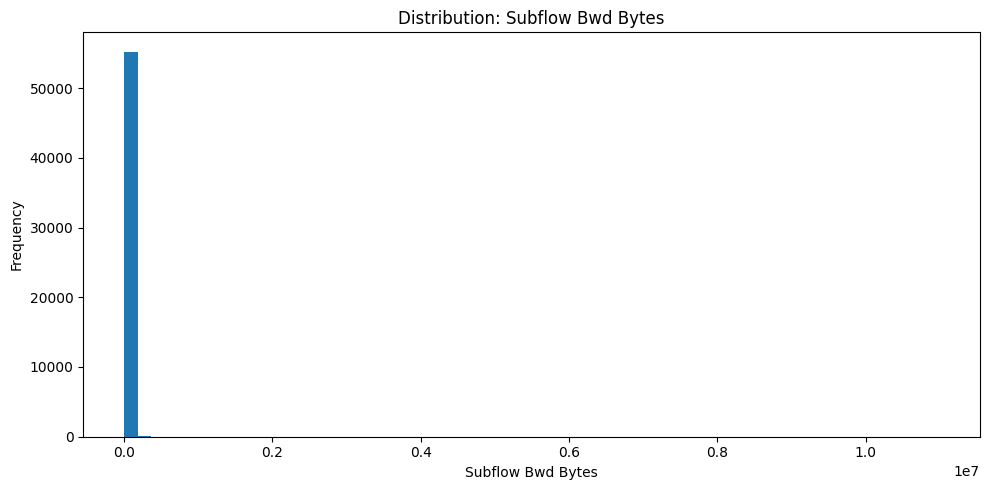

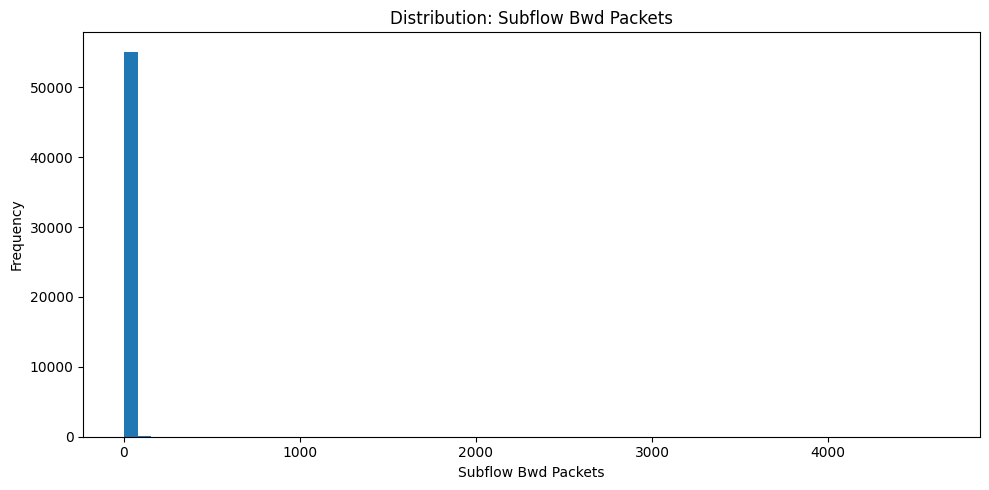

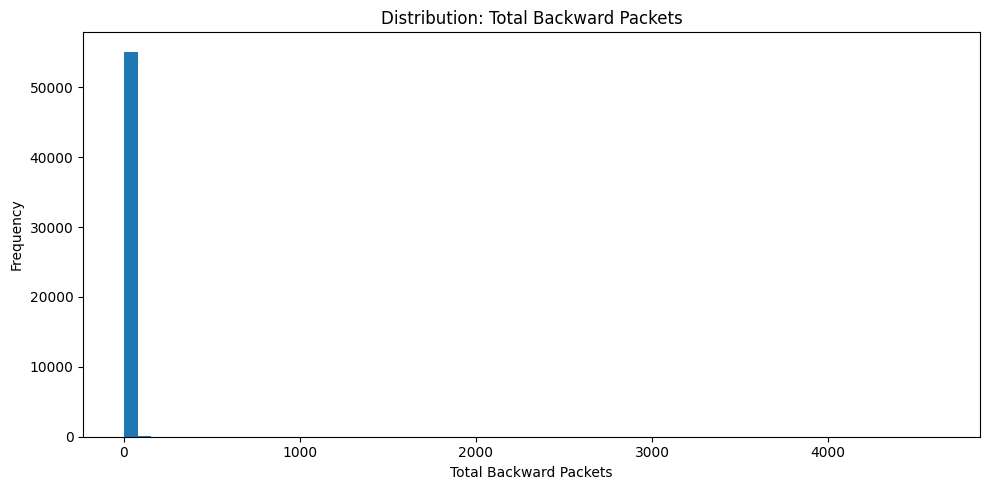

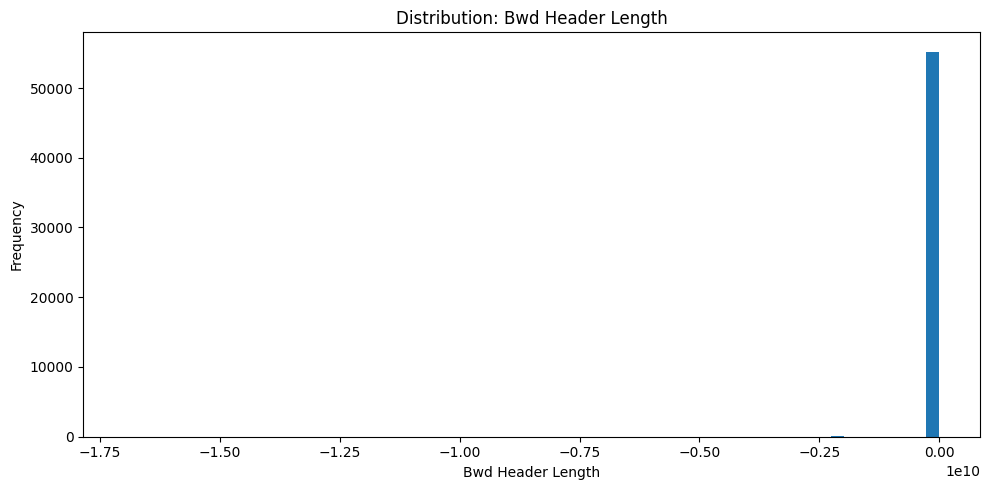

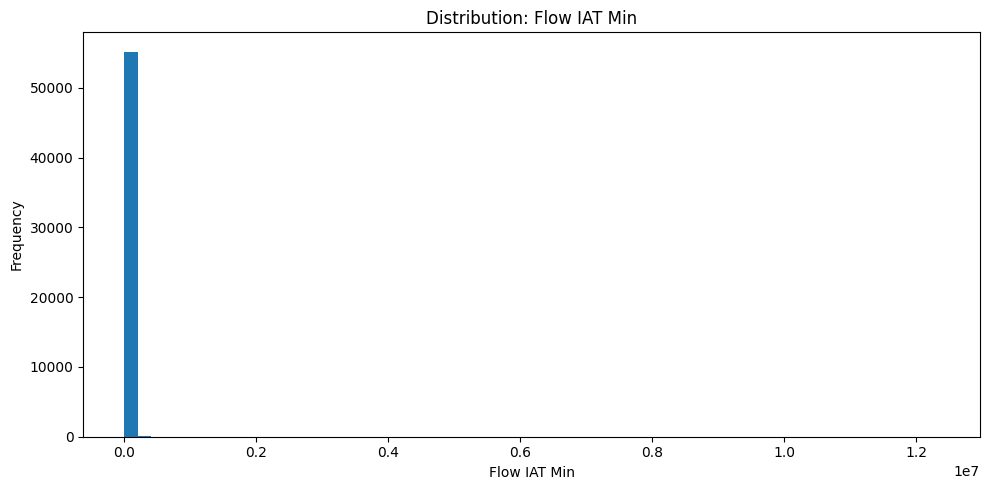

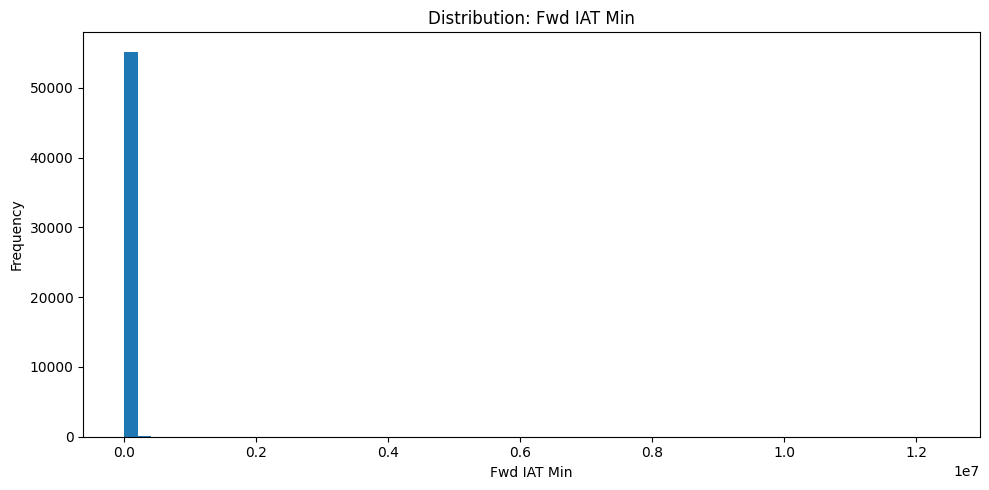

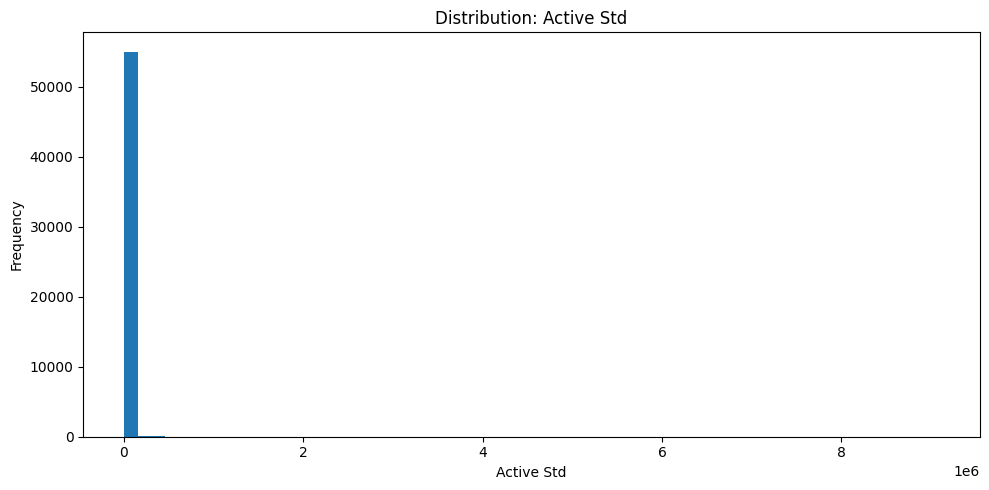

In [ ]:
plot_features = (
    feature_stats
    .sort_values("abs_skew", ascending=False)
    .head(12)["feature"]
    .tolist()
)

for c in plot_features:
    # Collect a bounded sample across files.
    samples = []

    for f in files:
        df = load_data(f, columns=[c])
        s = pd.to_numeric(df[c], errors="coerce")
        arr = s.to_numpy(dtype=np.float64, copy=False)
        finite = arr[np.isfinite(arr)]

        if len(finite):
            take = min(20_000, len(finite))
            rng = np.random.default_rng(42)
            if len(finite) > take:
                finite = rng.choice(finite, size=take, replace=False)
            samples.extend(finite.tolist())

        del df

        if len(samples) >= 50_000:
            break

    if not samples:
        continue

    plt.figure(figsize=(10, 5))
    plt.hist(samples, bins=60)
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.title(f"Distribution: {c}")
    plt.tight_layout()

    safe = "".join(
        ch if ch.isalnum() or ch in "-_"
        else "_"
        for ch in str(c)
    )

    plt.savefig(
        OUT / f"17_distribution_{safe}.png",
        dpi=160
    )
    plt.show()

## 10. Correlation analysis

In [ ]:
# Use a bounded row sample to keep correlation computation practical.
CORR_SAMPLE_PER_FILE = 20_000
corr_frames = []

rng = np.random.default_rng(42)

for f in files:
    df = load_data(f, columns=numeric)

    if len(df) > CORR_SAMPLE_PER_FILE:
        idx = rng.choice(
            len(df),
            size=CORR_SAMPLE_PER_FILE,
            replace=False
        )
        df = df.iloc[idx]

    corr_frames.append(
        df.replace([np.inf, -np.inf], np.nan)
    )

corr_sample = pd.concat(corr_frames, ignore_index=True)

corr = corr_sample.corr(numeric_only=True)

corr.to_csv(OUT / "17_feature_correlation_matrix.csv")

pairs = []

cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        value = corr.iloc[i, j]

        if pd.notna(value) and abs(value) >= 0.90:
            pairs.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "correlation": float(value),
                "absolute_correlation": abs(float(value))
            })

high_corr_df = pd.DataFrame(
    pairs,
    columns=[
        "feature_1",
        "feature_2",
        "correlation",
        "absolute_correlation"
    ]
).sort_values(
    "absolute_correlation",
    ascending=False
)

high_corr_df.to_csv(
    OUT / "17_high_correlation_pairs.csv",
    index=False
)

print("Correlation sample rows:", len(corr_sample))
print("High-correlation pairs |r| >= 0.90:", len(high_corr_df))

display(high_corr_df.head(50))

Correlation sample rows: 164528
High-correlation pairs |r| >= 0.90: 50


,feature_1,feature_2,correlation,absolute_correlation
1,Total Fwd Packets,Subflow Fwd Packets,1.000000,1.000000
3,Total Backward Packets,Subflow Bwd Packets,1.000000,1.000000
7,Bwd Packets Length Total,Subflow Bwd Bytes,1.000000,1.000000
5,Fwd Packets Length Total,Subflow Fwd Bytes,1.000000,1.000000
16,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,1.000000
18,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,1.000000
39,Fwd PSH Flags,RST Flag Count,1.000000,1.000000
0,Flow Duration,Fwd IAT Total,0.998871,0.998871
30,Flow IAT Min,Fwd IAT Min,0.998441,0.998441
20,Flow Packets/s,Fwd Packets/s,0.998211,0.998211


## 11. Duplicate analysis

In [ ]:
# The per-file duplicate count is already available from the
# quality analysis. This section provides the consolidated result.

total_duplicate_rows = int(quality_df["duplicate_rows"].sum())
duplicate_rate = (
    total_duplicate_rows / rows
    if "rows" in globals() and rows
    else total_duplicate_rows / max(
        int(summary["total_records"].iloc[0]), 1
    )
)

duplicate_summary = pd.DataFrame([{
    "total_records": int(summary["total_records"].iloc[0]),
    "duplicate_rows_within_files": total_duplicate_rows,
    "duplicate_rate_percent": 100.0 * duplicate_rate
}])

duplicate_summary.to_csv(
    OUT / "17_duplicate_summary.csv",
    index=False
)

display(duplicate_summary)

,total_records,duplicate_rows_within_files,duplicate_rate_percent
0,431371,0,0.0


## 12. ML suitability evaluation

This is a dataset-selection assessment rather than a claim of deployment performance.

The evaluation considers:
- class count
- class imbalance
- rare classes
- missing values
- infinite values
- duplicate prevalence
- constant features
- highly correlated features
- skewed numeric features
- scale sensitivity
- preprocessing burden
- DDoS specialization

No synthetic benchmark values are invented.

In [ ]:
total_records = int(summary["total_records"].iloc[0])

if label is not None and "class_df" in globals():
    n_classes = len(class_df)
    majority_pct = float(class_df["percentage"].max())
    minority_records = int(class_df["records"].min())
    rare_classes_100 = int((class_df["records"] < 100).sum())
else:
    n_classes = np.nan
    majority_pct = np.nan
    minority_records = np.nan
    rare_classes_100 = np.nan

missing_total = int(quality_summary["total_missing_values"].iloc[0])
inf_total = int(quality_summary["total_infinite_values"].iloc[0])
duplicate_total = int(quality_summary["total_duplicate_rows"].iloc[0])
constant_total = int(quality_summary["constant_features"].iloc[0])

high_skew_count = int(feature_stats["high_skew"].sum())
high_corr_count = len(high_corr_df)

assessment = pd.DataFrame([
    {
        "criterion": "Records",
        "value": total_records,
        "interpretation": "Large dataset suitable for ML experimentation, subject to compute constraints."
    },
    {
        "criterion": "Classes",
        "value": n_classes,
        "interpretation": "Multiclass complexity should be considered in model evaluation."
    },
    {
        "criterion": "Majority class percentage",
        "value": majority_pct,
        "interpretation": "Higher values indicate stronger class imbalance."
    },
    {
        "criterion": "Smallest class support",
        "value": minority_records,
        "interpretation": "Very small classes can make robust validation difficult."
    },
    {
        "criterion": "Classes below 100 records",
        "value": rare_classes_100,
        "interpretation": "Rare classes may require special evaluation or sampling."
    },
    {
        "criterion": "Missing values",
        "value": missing_total,
        "interpretation": "Missing values require explicit handling before ML."
    },
    {
        "criterion": "Infinite values",
        "value": inf_total,
        "interpretation": "Infinite values require replacement before most ML workflows."
    },
    {
        "criterion": "Duplicate rows",
        "value": duplicate_total,
        "interpretation": "Duplicates should be investigated to reduce leakage and redundancy."
    },
    {
        "criterion": "Constant features",
        "value": constant_total,
        "interpretation": "Constant features carry no predictive information."
    },
    {
        "criterion": "Highly correlated pairs |r| >= 0.90",
        "value": high_corr_count,
        "interpretation": "Redundant features may warrant removal for some models."
    },
    {
        "criterion": "Highly skewed numeric features",
        "value": high_skew_count,
        "interpretation": "Heavy-tailed variables may benefit from transformation or robust models."
    }
])

assessment.to_csv(
    OUT / "17_ml_suitability_assessment.csv",
    index=False
)

display(assessment)

,criterion,value,interpretation
0,Records,431371.00000,"Large dataset suitable for ML experimentation,..."
1,Classes,18.00000,Multiclass complexity should be considered in ...
2,Majority class percentage,28.13541,Higher values indicate stronger class imbalance.
3,Smallest class support,51.00000,Very small classes can make robust validation ...
4,Classes below 100 records,2.00000,Rare classes may require special evaluation or...
5,Missing values,0.00000,Missing values require explicit handling befor...
6,Infinite values,0.00000,Infinite values require replacement before mos...
7,Duplicate rows,0.00000,Duplicates should be investigated to reduce le...
8,Constant features,12.00000,Constant features carry no predictive informat...
9,Highly correlated pairs |r| >= 0.90,50.00000,Redundant features may warrant removal for som...


## 13. Preprocessing recommendations

In [ ]:
recommendations = pd.DataFrame([
    {
        "step": 1,
        "operation": "Label normalization",
        "recommendation": "Normalize label strings and map them to integer class IDs.",
        "reason": "Provides a stable target representation."
    },
    {
        "step": 2,
        "operation": "Infinite-value handling",
        "recommendation": "Replace positive/negative infinity with NaN before imputation.",
        "reason": "Most standard ML estimators cannot consume infinite values."
    },
    {
        "step": 3,
        "operation": "Missing-value handling",
        "recommendation": "Use a documented numeric imputation strategy after infinity replacement.",
        "reason": "Ensures the feature matrix contains finite values."
    },
    {
        "step": 4,
        "operation": "Duplicate handling",
        "recommendation": "Investigate duplicates and remove or isolate them before model evaluation where appropriate.",
        "reason": "Duplicate traffic can inflate apparent generalization performance."
    },
    {
        "step": 5,
        "operation": "Constant-feature removal",
        "recommendation": "Remove features identified as globally constant.",
        "reason": "They provide no predictive variation."
    },
    {
        "step": 6,
        "operation": "Correlation review",
        "recommendation": "Review highly correlated feature pairs and remove redundancy when justified.",
        "reason": "Can reduce dimensionality and improve interpretability."
    },
    {
        "step": 7,
        "operation": "Scaling",
        "recommendation": "Use standardization or robust scaling for scale-sensitive models.",
        "reason": "Network-flow variables can have very different magnitudes."
    },
    {
        "step": 8,
        "operation": "Tree-based baseline",
        "recommendation": "Include a tree-based classifier as a baseline.",
        "reason": "Tree models are less sensitive to feature scaling and can capture nonlinear relationships."
    },
    {
        "step": 9,
        "operation": "Class-aware evaluation",
        "recommendation": "Report macro-F1, weighted-F1, per-class recall and confusion matrices.",
        "reason": "Accuracy alone can hide poor minority-class detection."
    },
    {
        "step": 10,
        "operation": "Dataset-specific interpretation",
        "recommendation": "Treat CIC-DDoS2019 as a DDoS-focused benchmark rather than automatically selecting it as the general-purpose IDS dataset.",
        "reason": "Its attack scope is narrower than a broad multiclass IDS benchmark."
    }
])

recommendations.to_csv(
    OUT / "17_preprocessing_recommendations.csv",
    index=False
)

display(recommendations)

,step,operation,recommendation,reason
0,1,Label normalization,Normalize label strings and map them to intege...,Provides a stable target representation.
1,2,Infinite-value handling,Replace positive/negative infinity with NaN be...,Most standard ML estimators cannot consume inf...
2,3,Missing-value handling,Use a documented numeric imputation strategy a...,Ensures the feature matrix contains finite val...
3,4,Duplicate handling,Investigate duplicates and remove or isolate t...,Duplicate traffic can inflate apparent general...
4,5,Constant-feature removal,Remove features identified as globally constant.,They provide no predictive variation.
5,6,Correlation review,Review highly correlated feature pairs and rem...,Can reduce dimensionality and improve interpre...
6,7,Scaling,Use standardization or robust scaling for scal...,Network-flow variables can have very different...
7,8,Tree-based baseline,Include a tree-based classifier as a baseline.,Tree models are less sensitive to feature scal...
8,9,Class-aware evaluation,"Report macro-F1, weighted-F1, per-class recall...",Accuracy alone can hide poor minority-class de...
9,10,Dataset-specific interpretation,Treat CIC-DDoS2019 as a DDoS-focused benchmark...,Its attack scope is narrower than a broad mult...


## 14. Final CIC-DDoS2019 conclusion

The conclusion below is generated from the measurements calculated in this notebook. It is intentionally framed as a dataset-selection finding rather than an unsupported claim about model accuracy.

In [ ]:
conclusion_lines = []

conclusion_lines.append(
    "CIC-DDoS2019 was analysed using the current Kaggle Parquet representation."
)

conclusion_lines.append(
    f"The analysed collection contains {len(files)} source data files "
    f"and {total_records:,} records."
)

if label is not None and "class_df" in globals():
    conclusion_lines.append(
        f"The dataset contains {n_classes} observed classes. "
        f"The largest class represents {majority_pct:.2f}% of records, "
        f"while the smallest class contains {minority_records:,} records."
    )

conclusion_lines.append(
    f"The quality analysis identified {missing_total:,} missing values, "
    f"{inf_total:,} infinite values, and {duplicate_total:,} duplicate rows "
    f"within source files."
)

conclusion_lines.append(
    f"{constant_total} globally constant features were identified."
)

conclusion_lines.append(
    f"{high_corr_count} feature pairs had absolute correlation >= 0.90 "
    f"in the correlation sample."
)

conclusion_lines.append(
    f"{high_skew_count} numeric features had sample absolute skewness >= 2."
)

conclusion_lines.append(
    "For ML use, explicit handling of infinities, missing values, duplicates, "
    "feature redundancy, and class imbalance is recommended."
)

conclusion_lines.append(
    "For the overall CIC dataset comparison, CIC-DDoS2019 should be interpreted "
    "as a specialized DDoS benchmark. It provides useful evidence about DDoS "
    "detection but should not automatically replace a broader multiclass IDS "
    "dataset as the primary benchmark."
)

conclusion_text = "\n\n".join(conclusion_lines)

print(conclusion_text)

(OUT / "17_final_conclusion.txt").write_text(
    conclusion_text,
    encoding="utf-8"
)

pd.DataFrame({
    "dataset": ["CIC-DDoS2019"],
    "role": ["Specialized DDoS benchmark"],
    "primary_general_ids_recommendation": ["No"],
    "analysis_status": ["Complete"]
}).to_csv(
    OUT / "17_dataset_role.csv",
    index=False
)

CIC-DDoS2019 was analysed using the current Kaggle Parquet representation.

The analysed collection contains 17 source data files and 431,371 records.

The dataset contains 18 observed classes. The largest class represents 28.14% of records, while the smallest class contains 51 records.

The quality analysis identified 0 missing values, 0 infinite values, and 0 duplicate rows within source files.

12 globally constant features were identified.

50 feature pairs had absolute correlation >= 0.90 in the correlation sample.

58 numeric features had sample absolute skewness >= 2.

For ML use, explicit handling of infinities, missing values, duplicates, feature redundancy, and class imbalance is recommended.

For the overall CIC dataset comparison, CIC-DDoS2019 should be interpreted as a specialized DDoS benchmark. It provides useful evidence about DDoS detection but should not automatically replace a broader multiclass IDS dataset as the primary benchmark.


## 15. Package all results for download

In [ ]:
import shutil

zip_base = Path("/content/CIC-DDoS2019_results")

if zip_base.with_suffix(".zip").exists():
    zip_base.with_suffix(".zip").unlink()

shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUT
)

zip_path = zip_base.with_suffix(".zip")

print("Analysis complete.")
print("Results directory:", OUT)
print("ZIP:", zip_path)
print("\nResult files:")

for p in sorted(OUT.iterdir()):
    print(" ", p.name)

print("\nDownload the generated ZIP from the Colab file browser:")
print(zip_path)

Analysis complete.
Results directory: /content/cicddos2019_work/results
ZIP: /content/CIC-DDoS2019_results.zip

Result files:
  17_class_distribution.csv
  17_class_distribution.png
  17_class_distribution_by_file.csv
  17_dataset_role.csv
  17_dataset_summary.csv
  17_distribution_Active_Std.png
  17_distribution_Bwd_Header_Length.png
  17_distribution_Bwd_Packets_Length_Total.png
  17_distribution_Flow_IAT_Min.png
  17_distribution_Fwd_IAT_Min.png
  17_distribution_Fwd_Packets_Length_Total.png
  17_distribution_Subflow_Bwd_Bytes.png
  17_distribution_Subflow_Bwd_Packets.png
  17_distribution_Subflow_Fwd_Bytes.png
  17_distribution_Subflow_Fwd_Packets.png
  17_distribution_Total_Backward_Packets.png
  17_distribution_Total_Fwd_Packets.png
  17_duplicate_summary.csv
  17_duplicates_by_file.csv
  17_feature_correlation_matrix.csv
  17_feature_quality.csv
  17_file_data_quality.csv
  17_file_inventory.csv
  17_final_conclusion.txt
  17_high_correlation_pairs.csv
  17_ml_suitability_asses